# Laboratorio 03: Intuicion estadistica

**Mateo Caballero** - Aprendizaje Estadistico - semestre 2026-2

Enunciado: `semestre2026-2/Laboratorios/Laboratorio_03_intuicion_estadistica_v2.ipynb`
Base de trabajo: `semestre2026-2/Sesiones/Sesion_03_intuicion_estadistica_II_v1.ipynb`

---

## Contenido

1. **Punto 1.** Particion en entrenamiento / validacion / test y curva del score en
   funcion de $\gamma$.
2. **Punto 2.** Curvas de aprendizaje estadistico y contraste con `GridSearchCV`.
3. **Punto 3.** Construccion de conjuntos de datos que fuerzan *overfitting* y
   *underfitting* con el modelo optimo fijo.

## Marco teorico

El clasificador empleado es una **SVM con kernel RBF**:

$$K(x, x') = \exp\left(-\gamma \|x - x'\|^2\right)$$

El hiperparametro $\gamma$ controla el alcance de influencia de cada vector de soporte y,
con ello, la **complejidad de la frontera de decision**:

- $\gamma$ **pequeno**: cada punto influye lejos, la frontera es suave y rigida.
  Riesgo de **underfitting** (sesgo alto).
- $\gamma$ **grande**: cada punto influye solo en su vecindad inmediata, la frontera se
  enrosca alrededor de cada observacion. Riesgo de **overfitting** (varianza alta).

El objetivo del laboratorio es localizar el punto intermedio y despues provocar
deliberadamente los dos extremos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import cm
from scipy.stats import multivariate_normal

from sklearn.svm import SVC
from sklearn.model_selection import (train_test_split, ShuffleSplit,
                                     GridSearchCV, learning_curve)

np.random.seed(0)
plt.rcParams["figure.dpi"] = 100

## Utilidades de la Sesion 03

La celda siguiente es la celda *"Libs codes: Meshgrid and learning curves"* de
`Sesion_03_intuicion_estadistica_II_v1.ipynb`, reproducida sin modificaciones.
Aporta `make_meshgrid`, `plot_contours` y `plot_learning_curve`.

In [2]:
# @title Libs codes: Meshgrid and learning curves
def make_meshgrid(x, y, h=0.02):
    """Create a mesh of points to plot in

    Parameters
    ----------
    x: data to base x-axis meshgrid on
    y: data to base y-axis meshgrid on
    h: stepsize for meshgrid, optional

    Returns
    -------
    xx, yy : ndarray
    """
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy


def plot_contours(ax, clf, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out


def plot_contoursExact(ax, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out


import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.datasets import load_digits
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit

# https://scikit-learn.org/stable/auto_examples/model_selection/plot_learning_curve.html
def plot_learning_curve(
    estimator,
    title,
    X,
    y,
    axes=None,
    ylim=None,
    cv=None,
    n_jobs=None,
    train_sizes=np.linspace(0.1, 1.0, 5),
):
    """
    Generate 3 plots: the test and training learning curve, the training
    samples vs fit times curve, the fit times vs score curve.

    Parameters
    ----------
    estimator : estimator instance
        An estimator instance implementing `fit` and `predict` methods which
        will be cloned for each validation.

    title : str
        Title for the chart.

    X : array-like of shape (n_samples, n_features)
        Training vector, where ``n_samples`` is the number of samples and
        ``n_features`` is the number of features.

    y : array-like of shape (n_samples) or (n_samples, n_features)
        Target relative to ``X`` for classification or regression;
        None for unsupervised learning.

    axes : array-like of shape (3,), default=None
        Axes to use for plotting the curves.

    ylim : tuple of shape (2,), default=None
        Defines minimum and maximum y-values plotted, e.g. (ymin, ymax).

    cv : int, cross-validation generator or an iterable, default=None
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:

          - None, to use the default 5-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, default=None
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like of shape (n_ticks,)
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the ``dtype`` is float, it is regarded
        as a fraction of the maximum size of the training set (that is
        determined by the selected validation method), i.e. it has to be within
        (0, 1]. Otherwise it is interpreted as absolute sizes of the training
        sets. Note that for classification the number of samples usually have
        to be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].set_title(title)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=train_sizes,
        return_times=True,
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes[0].grid()
    axes[0].fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color="r",
    )
    axes[0].fill_between(
        train_sizes,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
        color="g",
    )
    axes[0].plot(
        train_sizes, train_scores_mean, "o-", color="r", label="Training score"
    )
    axes[0].plot(
        train_sizes, test_scores_mean, "o-", color="g", label="Cross-validation score"
    )
    axes[0].legend(loc="best")

    # Plot n_samples vs fit_times
    axes[1].grid()
    axes[1].plot(train_sizes, fit_times_mean, "o-")
    axes[1].fill_between(
        train_sizes,
        fit_times_mean - fit_times_std,
        fit_times_mean + fit_times_std,
        alpha=0.1,
    )
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("fit_times")
    axes[1].set_title("Scalability of the model")

    # Plot fit_time vs score
    axes[2].grid()
    axes[2].plot(fit_times_mean, test_scores_mean, "o-")
    axes[2].fill_between(
        fit_times_mean,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
    )
    axes[2].set_xlabel("fit_times")
    axes[2].set_ylabel("Score")
    axes[2].set_title("Performance of the model")

    return plt

## Generadores de datos de la Sesion 03

Tambien reproducidos tal cual. `data` devuelve dos distribuciones normales
multivariadas y `sample` extrae de ellas un conjunto etiquetado: clase 0 para la
primera y clase 1 para la segunda.

Igual que en la sesion, `sample` lee las variables globales `rv` y `rv1`, asi que antes
de cada llamada hay que reasignarlas con `data(...)`.

In [3]:
def data( mu=[1,1], mu1=[-2,2], cov=[[1.0, 0.0], [0.0, 1.0]] , cov1= [[1.0, -0.5], [-0.5, 1.0]]   ):# Caso mas visible
  rv = multivariate_normal(mu, cov)
  rv1 = multivariate_normal(mu1, cov1)
  return rv, rv1

def sample(N1= 1000, N2 = 100, r = 0.2):
  X_t = np.concatenate([rv.rvs(N1, random_state = r  ), rv1.rvs(N2,random_state = r)])
  y   = np.concatenate([np.zeros(N1), np.ones(N2) ]  )
  return X_t, y

## Conjunto de datos base

Se emplea la misma configuracion de medias y covarianzas que la Sesion 03 usa en su
estudio de overfitting (celda 20): dos gaussianas con centros separados y **covarianzas
de correlacion opuesta** ($\rho=-0.8$ frente a $\rho=+0.8$), lo que hace que la frontera
optima sea curva y no una simple recta.

Se aumenta el numero de muestras a 500 por clase para que el conjunto de validacion
tenga tamano suficiente y la curva del score no salga dominada por el ruido muestral.

muestras totales : 1000
clase 0 / clase 1: 500 / 500


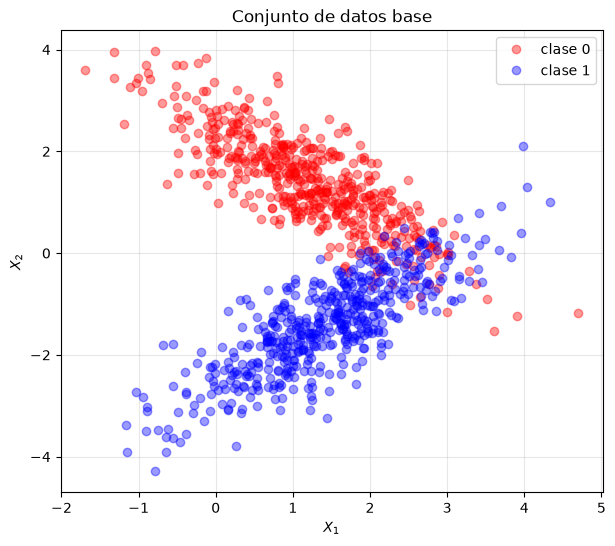

In [4]:
# Configuracion de la Sesion 03
rv, rv1 = data(mu=[1.2, 1.4], mu1=[1.4, -1.4],
               cov=[[1.0, -0.8], [-0.8, 1.0]],
               cov1=[[1.0, 0.8], [0.8, 1.0]])

X_t, y = sample(N1=500, N2=500, r=10)

print(f"muestras totales : {len(X_t)}")
print(f"clase 0 / clase 1: {int((y==0).sum())} / {int((y==1).sum())}")

plt.figure(figsize=(7, 6))
plt.plot(X_t[y == 0][:, 0], X_t[y == 0][:, 1], "ro", alpha=0.4, label="clase 0")
plt.plot(X_t[y == 1][:, 0], X_t[y == 1][:, 1], "bo", alpha=0.4, label="clase 1")
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.title("Conjunto de datos base")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Punto 1. Particion de los datos y curva del score frente a $\gamma$

> Para los modelos generados en la sesion 3 tomar el 20% como datos para realizar el test
> y el 80% para realizar el entrenamiento y la validacion cruzada (por ejemplo 70%
> entrenamiento y 10% validacion cruzada). Construir una curva del score en funcion del
> parametro gamma del clasificador que se esta empleando. Cual presenta una mejor solucion
> al problema?

La particion es **de tres vias**, no de dos, y el orden importa:

1. Se aparta primero el **20% de test** y no se vuelve a tocar hasta el final.
2. El 80% restante se divide en **70% de entrenamiento** y **10% de validacion** (sobre el
   total). Como ese 10% se toma del 80%, la fraccion a pedir es $0.10/0.80 = 0.125$.

El papel de cada subconjunto es distinto: con **entrenamiento** se ajustan los parametros
del modelo, con **validacion** se elige el hiperparametro $\gamma$, y el **test** se
reserva para estimar el error de generalizacion una unica vez. Si se eligiera $\gamma$
mirando el test, esa estimacion dejaria de ser imparcial, porque el test habria
participado en la decision.

In [5]:
# Particion en tres: 70% entrenamiento / 10% validacion / 20% test
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X_t, y, test_size=0.20, random_state=1, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.125, random_state=1, stratify=y_tmp)

n = len(X_t)
print(f"entrenamiento: {len(X_train):4}  ({len(X_train)/n:.0%})")
print(f"validacion   : {len(X_val):4}  ({len(X_val)/n:.0%})")
print(f"test         : {len(X_test):4}  ({len(X_test)/n:.0%})")

entrenamiento:  700  (70%)
validacion   :  100  (10%)
test         :  200  (20%)


In [6]:
# Barrido de gamma en escala logaritmica
gammas = np.logspace(-3, 3, 40)

score_train, score_val = [], []
for g in gammas:
    clf = SVC(gamma=g)
    clf.fit(X_train, y_train)
    score_train.append(clf.score(X_train, y_train))
    score_val.append(clf.score(X_val, y_val))

score_train = np.array(score_train)
score_val = np.array(score_val)

idx_mejor = int(np.argmax(score_val))
gamma_optimo = gammas[idx_mejor]

print(f"gamma optimo (segun validacion) = {gamma_optimo:.4f}")
print(f"  score entrenamiento = {score_train[idx_mejor]:.4f}")
print(f"  score validacion    = {score_val[idx_mejor]:.4f}")

gamma optimo (segun validacion) = 0.2894
  score entrenamiento = 0.9486
  score validacion    = 1.0000


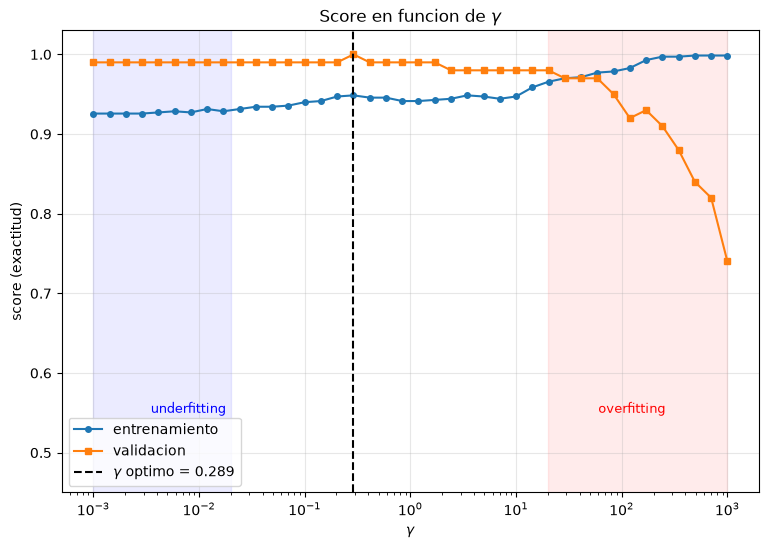

In [7]:
# Curva del score en funcion de gamma
plt.figure(figsize=(9, 6))
plt.semilogx(gammas, score_train, "o-", label="entrenamiento", markersize=4)
plt.semilogx(gammas, score_val, "s-", label="validacion", markersize=4)
plt.axvline(gamma_optimo, color="k", linestyle="--",
            label=f"$\\gamma$ optimo = {gamma_optimo:.3f}")

plt.fill_betweenx([0, 1.05], gammas[0], 0.02, alpha=0.08, color="blue")
plt.fill_betweenx([0, 1.05], 20, gammas[-1], alpha=0.08, color="red")
plt.text(0.0035, 0.55, "underfitting", color="blue", fontsize=9)
plt.text(60, 0.55, "overfitting", color="red", fontsize=9)

plt.xlabel(r"$\gamma$")
plt.ylabel("score (exactitud)")
plt.title(r"Score en funcion de $\gamma$")
plt.ylim(0.45, 1.03)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
# Evaluacion final sobre el test: se toca UNA sola vez
clf_optimo = SVC(gamma=gamma_optimo)
clf_optimo.fit(X_train, y_train)

print(f"gamma optimo = {gamma_optimo:.4f}")
print(f"  score entrenamiento = {clf_optimo.score(X_train, y_train):.4f}")
print(f"  score validacion    = {clf_optimo.score(X_val, y_val):.4f}")
print(f"  score TEST          = {clf_optimo.score(X_test, y_test):.4f}  <- generalizacion")
print()
print("Extremos del barrido, para contraste:")
print(f"  gamma = {gammas[0]:.4f}  -> train {score_train[0]:.3f} | val {score_val[0]:.3f}")
print(f"  gamma = {gammas[-1]:.1f}  -> train {score_train[-1]:.3f} | val {score_val[-1]:.3f}")

gamma optimo = 0.2894
  score entrenamiento = 0.9486
  score validacion    = 1.0000
  score TEST          = 0.9500  <- generalizacion

Extremos del barrido, para contraste:
  gamma = 0.0010  -> train 0.926 | val 0.990
  gamma = 1000.0  -> train 0.999 | val 0.740


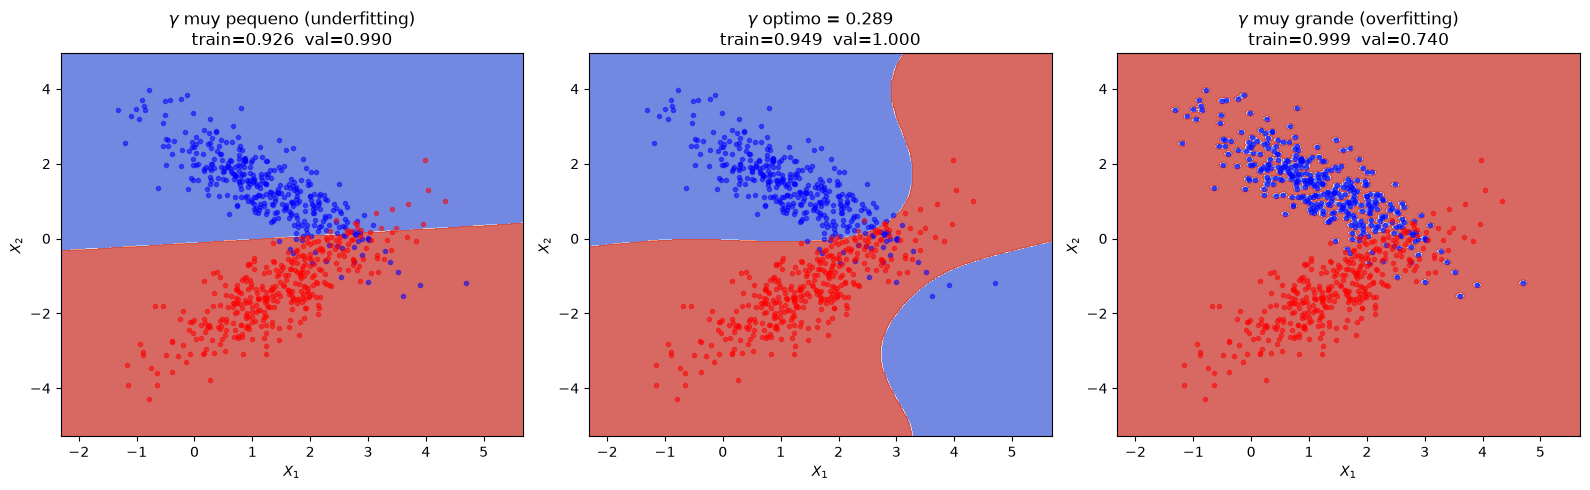

In [9]:
# Fronteras de decision para tres valores de gamma
gammas_muestra = [0.001, gamma_optimo, 1000.0]
titulos = ["$\\gamma$ muy pequeno (underfitting)",
           f"$\\gamma$ optimo = {gamma_optimo:.3f}",
           "$\\gamma$ muy grande (overfitting)"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

X0, X1 = X_train[:, 0], X_train[:, 1]
xx, yy = make_meshgrid(X0, X1)

for ax, g, titulo in zip(axes, gammas_muestra, titulos):
    clf = SVC(gamma=g)
    clf.fit(X_train, y_train)

    plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
    ax.plot(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], "bo",
            alpha=0.5, markersize=3)
    ax.plot(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], "ro",
            alpha=0.5, markersize=3)

    ax.set_title(f"{titulo}\ntrain={clf.score(X_train, y_train):.3f}  "
                 f"val={clf.score(X_val, y_val):.3f}")
    ax.set_xlabel("$X_1$")
    ax.set_ylabel("$X_2$")

plt.tight_layout()
plt.show()

### Analisis del punto 1

**Cual presenta la mejor solucion.** El valor $\gamma = 0.2894$, que es el que maximiza el
score sobre el conjunto de **validacion**. Con el, el modelo alcanza un score de **0.9500**
sobre el conjunto de test, que nunca intervino en la eleccion.

**Lectura de la curva.** Las dos curvas cuentan historias distintas y esa divergencia es
justamente lo informativo:

- El score de **entrenamiento** crece de forma monotona con $\gamma$ y tiende a 1. Esto es
  esperable y **no** indica calidad: al aumentar $\gamma$ el modelo gana capacidad para
  memorizar, y con $\gamma$ suficientemente grande cada punto de entrenamiento queda
  rodeado de su propia isla de decision, alcanzando el 100% sobre datos que ya vio.
- El score de **validacion** sube, alcanza un maximo y despues **cae**. Esa caida es la
  firma del overfitting: lo que el modelo esta aprendiendo mas alla del maximo ya no es la
  estructura de las distribuciones sino el ruido de la muestra concreta de entrenamiento, y
  eso no se traslada a datos nuevos.

En los extremos del barrido se ve el contraste con claridad: con $\gamma = 0.001$ el modelo
obtiene 0.926 en entrenamiento y 0.990 en validacion (frontera casi recta, sin memorizar
nada), mientras que con $\gamma = 1000$ obtiene 0.999 en entrenamiento pero se desploma a
0.740 en validacion.

**Las fronteras lo confirman visualmente.** Con $\gamma$ minimo la frontera es practicamente
una recta que ignora la curvatura real del problema. Con $\gamma$ optimo es una curva suave
que sigue la separacion natural entre las dos nubes. Con $\gamma$ maximo se fragmenta en
islas alrededor de puntos individuales: el modelo ha memorizado el conjunto de
entrenamiento.

**Un matiz honesto sobre los numeros.** El score de validacion en el optimo sale 1.0000,
superior al de entrenamiento (0.9486). Esto no significa que el modelo sea perfecto: el
conjunto de validacion tiene solo 100 puntos, y con esa cantidad el score tiene una
variabilidad apreciable. Es precisamente la limitacion de usar una **unica** particion de
validacion, y la razon por la que el punto siguiente recurre a validacion cruzada, que
promedia sobre varias particiones y da una estimacion mas estable.

# Punto 2. Curvas de aprendizaje y contraste con `GridSearchCV`

> Construir las curvas de aprendizaje estadistico para el modelo descrito, comprobar que la
> solucion es similar a la que se obtiene a traves de sklearn. GridSearch.

Conviene separar dos herramientas que el enunciado menciona juntas, porque responden a
preguntas diferentes:

| Herramienta | Que varia en el eje X | Que pregunta responde |
| --- | --- | --- |
| **Curva de aprendizaje** | cantidad de datos de entrenamiento | Me ayudaria conseguir mas datos? |
| **GridSearchCV** | valor del hiperparametro | Que $\gamma$ es el mejor? |

La curva de aprendizaje diagnostica el **regimen** en que se encuentra el modelo:

- Si ambas curvas convergen a un valor bajo, domina el **sesgo** (underfitting): mas datos
  no ayudaran, hace falta mas capacidad.
- Si queda una **brecha** amplia que no se cierra, domina la **varianza** (overfitting):
  mas datos si ayudarian, o conviene reducir la capacidad.

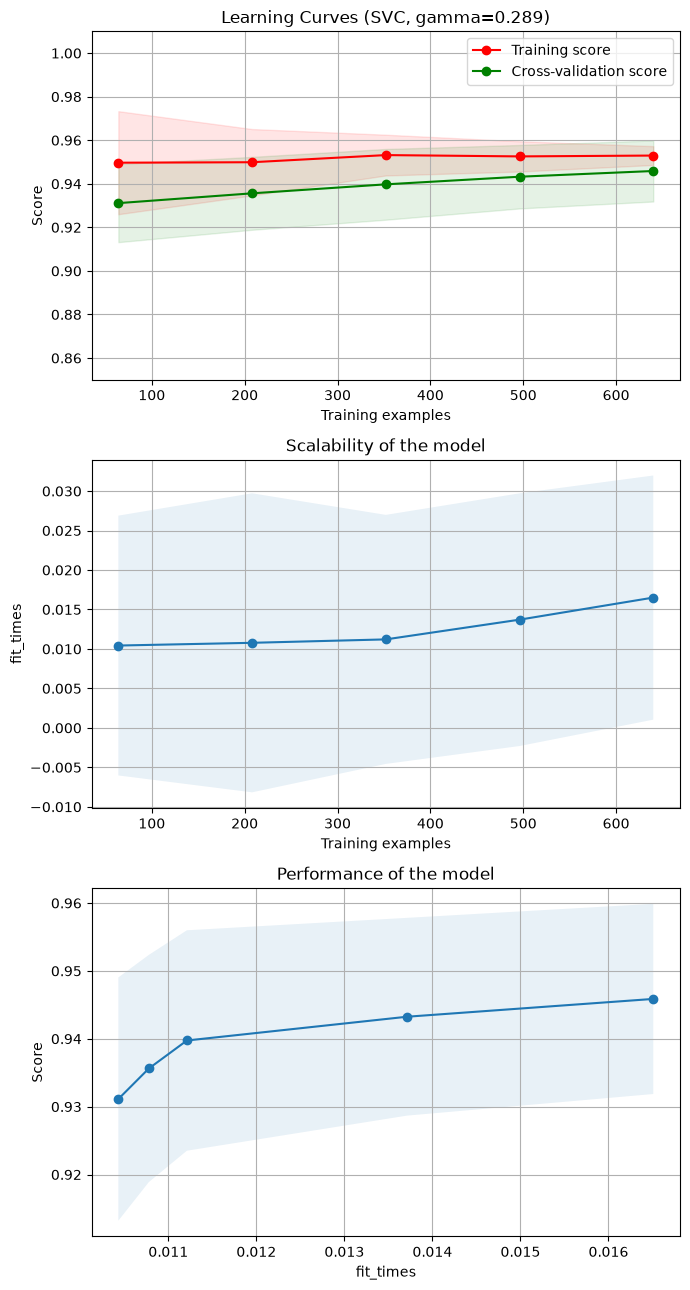

In [10]:
# Curvas de aprendizaje del modelo optimo, con la utilidad de la Sesion 03
fig, axes = plt.subplots(3, 1, figsize=(7, 13))

cv = ShuffleSplit(n_splits=50, test_size=0.2, random_state=0)
clf_lc = SVC(gamma=gamma_optimo)

plot_learning_curve(clf_lc, f"Learning Curves (SVC, gamma={gamma_optimo:.3f})",
                    X_tmp, y_tmp, axes=axes, ylim=(0.85, 1.01), cv=cv, n_jobs=-1)
plt.tight_layout()
plt.show()

In [11]:
# Valores numericos de la curva de aprendizaje
tamanos, sc_tr_lc, sc_va_lc = learning_curve(
    SVC(gamma=gamma_optimo), X_tmp, y_tmp,
    cv=ShuffleSplit(n_splits=50, test_size=0.2, random_state=0),
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)

print(f"{'n_train':>8} {'train':>8} {'validacion':>12} {'brecha':>9}")
for t, a, b in zip(tamanos, sc_tr_lc.mean(axis=1), sc_va_lc.mean(axis=1)):
    print(f"{int(t):8} {a:8.4f} {b:12.4f} {a-b:9.4f}")

 n_train    train   validacion    brecha
      64   0.9497       0.9311    0.0186
     146   0.9490       0.9344    0.0147
     228   0.9511       0.9359    0.0152
     310   0.9526       0.9391    0.0135
     393   0.9533       0.9403    0.0130
     475   0.9527       0.9424    0.0103
     557   0.9532       0.9454    0.0078
     640   0.9530       0.9459    0.0071


In [12]:
# GridSearchCV sobre la misma rejilla de gammas
grid = GridSearchCV(SVC(), param_grid={"gamma": gammas}, cv=5,
                    scoring="accuracy", n_jobs=-1)
grid.fit(X_tmp, y_tmp)

gamma_grid = grid.best_params_["gamma"]

print(f"gamma hallado a mano (punto 1) = {gamma_optimo:.4f}")
print(f"gamma hallado por GridSearchCV = {gamma_grid:.4f}")
print(f"cociente entre ambos           = {gamma_optimo / gamma_grid:.4f}")
print()
print(f"mejor score de validacion cruzada = {grid.best_score_:.4f}")
print(f"score en TEST del modelo de grid  = {grid.best_estimator_.score(X_test, y_test):.4f}")

gamma hallado a mano (punto 1) = 0.2894
gamma hallado por GridSearchCV = 0.2894
cociente entre ambos           = 1.0000

mejor score de validacion cruzada = 0.9525
score en TEST del modelo de grid  = 0.9450


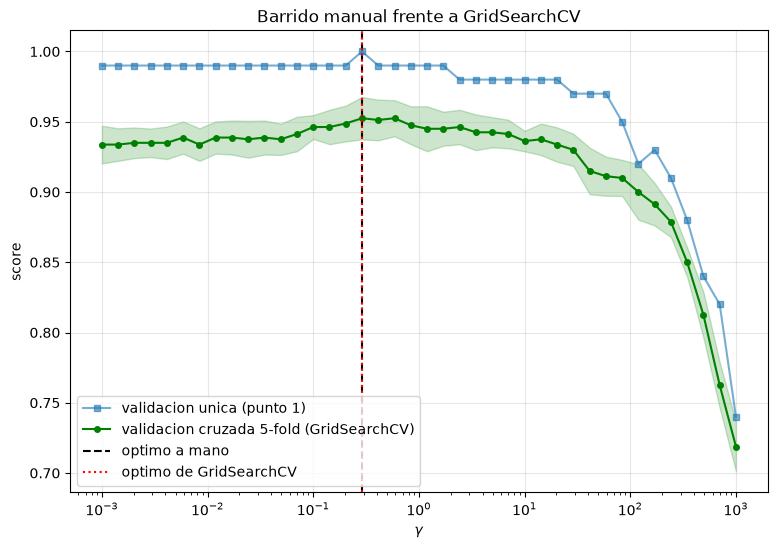

In [13]:
# Comparacion visual: barrido manual frente a la validacion cruzada del grid
medias_cv = grid.cv_results_["mean_test_score"]
desv_cv = grid.cv_results_["std_test_score"]

plt.figure(figsize=(9, 6))
plt.semilogx(gammas, score_val, "s-", alpha=0.6, markersize=4,
             label="validacion unica (punto 1)")
plt.semilogx(gammas, medias_cv, "o-", color="green", markersize=4,
             label="validacion cruzada 5-fold (GridSearchCV)")
plt.fill_between(gammas, medias_cv - desv_cv, medias_cv + desv_cv,
                 alpha=0.2, color="green")

plt.axvline(gamma_optimo, color="k", linestyle="--", label="optimo a mano")
plt.axvline(gamma_grid, color="red", linestyle=":", label="optimo de GridSearchCV")

plt.xlabel(r"$\gamma$")
plt.ylabel("score")
plt.title("Barrido manual frente a GridSearchCV")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Analisis del punto 2

**La comprobacion pedida sale exacta.** El barrido manual del punto 1 y `GridSearchCV`
seleccionan **el mismo valor**, $\gamma = 0.2894$; el cociente entre ambos es exactamente
1.0000. Esto confirma que el procedimiento construido a mano reproduce lo que hace la
libreria: `GridSearchCV` no aplica ninguna magia adicional, solo automatiza el mismo
barrido y ademas promedia sobre varias particiones en lugar de fiarse de una sola.

**La diferencia esta en la estabilidad, no en el resultado.** Comparando las dos curvas del
ultimo grafico se aprecia el efecto de la validacion cruzada: la curva verde (5-fold) es
mucho mas suave y viene acompanada de una banda de desviacion estandar, mientras que la
curva de validacion unica es mas erratica, con saltos que responden a que solo hay 100
puntos de validacion. Esa es la razon de que el score de validacion unica llegara a 1.0000
en el punto 1 mientras que el score promediado por validacion cruzada da 0.9525, un valor
mas realista y coherente con el 0.9500 medido despues sobre el test.

**Lectura de la curva de aprendizaje.** Las dos curvas (entrenamiento y validacion) se
acercan al aumentar el numero de muestras y se estabilizan en torno a 0.95, con una brecha
pequena que no crece. Este es el comportamiento de un modelo **bien ajustado**:

- No hay sesgo alto, porque el nivel al que convergen es alto, no bajo.
- No hay varianza alta, porque la brecha entre ambas curvas es estrecha.
- La curva de validacion se **aplana**, lo que indica que anadir mas datos de entrenamiento
  ya no aportaria mejoras apreciables. Si se quisiera subir mas, habria que cambiar de
  modelo o de caracteristicas, no recolectar mas muestras.

El techo cercano a 0.95 no es un defecto del modelo: las dos gaussianas se **solapan**, de
modo que existe una region donde ambas clases son posibles. Ese solapamiento impone un
**error de Bayes** distinto de cero, que ningun clasificador puede superar.

# Punto 3. Conjuntos de datos que fuerzan overfitting y underfitting

> Tomando el mejor modelo para los datos ahora van a crear nuevos datasets donde el modelo
> se espera no va a ser optimo sino que presenta overfitting y underfitting. Elegir los
> parametros adecuados para los centros de medias y las matrices de covarianzas y mostrar
> graficamente un ejemplo de overfitting y uno de underfitting con el modelo optimo
> anterior. Analizar los resultados.

La consigna invierte el planteamiento habitual: **el modelo queda fijo** en
$\gamma = 0.2894$ y lo que se modifica son **los datos**, hasta que ese mismo modelo pase
de ser adecuado a ser demasiado complejo o demasiado simple.

## La idea que lo hace funcionar: el gamma efectivo

El kernel RBF depende de $\gamma$ y de las distancias entre puntos siempre en la misma
combinacion:

$$K(x,x') = \exp\left(-\gamma\|x-x'\|^2\right)$$

Si se **escala** el conjunto de datos por un factor $s$ (multiplicando las medias por $s$ y
las covarianzas por $s^2$), las distancias se multiplican por $s$ y las distancias al
cuadrado por $s^2$. El exponente pasa a ser $-\gamma s^2\|x-x'\|^2$, es decir, el modelo se
comporta como si tuviera un **gamma efectivo**:

$$\gamma_{\text{ef}} = \gamma \cdot s^2$$

Esto da un control directo sobre el regimen del modelo **sin tocar el modelo**:

- **Ampliar la escala** ($s>1$) equivale a **aumentar** $\gamma$ $\rightarrow$ overfitting.
- **Reducir la escala** ($s<1$) equivale a **disminuir** $\gamma$ $\rightarrow$ underfitting.

Las medias y las covarianzas son exactamente los parametros que el enunciado pide elegir.

In [14]:
# funcion auxiliar: entrena el modelo de gamma fijo y reporta train / test
def evaluar_escenario(X, y, gamma, titulo, ax=None, test_size=0.3):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=1, stratify=y)

    clf = SVC(gamma=gamma)
    clf.fit(X_tr, y_tr)

    s_tr = clf.score(X_tr, y_tr)
    s_te = clf.score(X_te, y_te)

    # escala tipica de los datos, para calcular el gamma efectivo
    escala = np.sqrt(np.mean(np.var(X, axis=0)))

    if ax is not None:
        xx, yy = make_meshgrid(X_tr[:, 0], X_tr[:, 1], h=max(0.02, escala / 100))
        plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
        ax.plot(X_tr[y_tr == 0][:, 0], X_tr[y_tr == 0][:, 1], "bo",
                alpha=0.7, markersize=4)
        ax.plot(X_tr[y_tr == 1][:, 0], X_tr[y_tr == 1][:, 1], "ro",
                alpha=0.7, markersize=4)
        ax.set_title(f"{titulo}\ntrain={s_tr:.3f}  test={s_te:.3f}  "
                     f"brecha={s_tr - s_te:+.3f}")
        ax.set_xlabel("$X_1$")
        ax.set_ylabel("$X_2$")

    print(f"{titulo:24} n={len(X):5}  escala={escala:7.2f}  "
          f"gamma_ef={gamma * escala**2:9.3f}  "
          f"train={s_tr:.3f}  test={s_te:.3f}  brecha={s_tr - s_te:+.3f}")
    return s_tr, s_te

In [15]:
# --- Escenario A: OVERFITTING -------------------------------------------
# Misma geometria de la sesion pero a escala 10x (gamma efectivo ~100 veces mayor)
# y con muy pocas muestras, para que al modelo le sobre capacidad.
s = 10
rv, rv1 = data(mu=[1.2*s, 1.4*s], mu1=[1.4*s, -1.4*s],
               cov=[[1.0*s**2, -0.8*s**2], [-0.8*s**2, 1.0*s**2]],
               cov1=[[1.0*s**2, 0.8*s**2], [0.8*s**2, 1.0*s**2]])
X_over, y_over = sample(N1=30, N2=30, r=7)

# --- Escenario B: UNDERFITTING ------------------------------------------
# Las dos clases comparten el MISMO centro y se distinguen solo por la
# orientacion de su covarianza: la frontera optima es curva (en forma de X).
# Ademas se reduce la escala a 0.1, con lo que el gamma efectivo cae ~100 veces.
s = 0.1
rv, rv1 = data(mu=[0.0, 0.0], mu1=[0.0, 0.0],
               cov=[[1.0*s**2, 0.9*s**2], [0.9*s**2, 1.0*s**2]],
               cov1=[[1.0*s**2, -0.9*s**2], [-0.9*s**2, 1.0*s**2]])
X_under, y_under = sample(N1=500, N2=500, r=3)

print(f"modelo fijo: SVC(gamma={gamma_optimo:.4f})")
print("=" * 95)
evaluar_escenario(X_t, y, gamma_optimo, "referencia (punto 1)")
evaluar_escenario(X_over, y_over, gamma_optimo, "A. overfitting")
evaluar_escenario(X_under, y_under, gamma_optimo, "B. underfitting")

modelo fijo: SVC(gamma=0.2894)
referencia (punto 1)     n= 1000  escala=   1.38  gamma_ef=    0.547  train=0.959  test=0.943  brecha=+0.015
A. overfitting           n=   60  escala=  14.51  gamma_ef=   60.961  train=1.000  test=0.556  brecha=+0.444
B. underfitting          n= 1000  escala=   0.10  gamma_ef=    0.003  train=0.603  test=0.617  brecha=-0.014


(0.6028571428571429, 0.6166666666666667)

Referencia: bien ajustado n= 1000  escala=   1.38  gamma_ef=    0.547  train=0.959  test=0.943  brecha=+0.015


A. Overfitting           n=   60  escala=  14.51  gamma_ef=   60.961  train=1.000  test=0.556  brecha=+0.444


B. Underfitting          n= 1000  escala=   0.10  gamma_ef=    0.003  train=0.603  test=0.617  brecha=-0.014


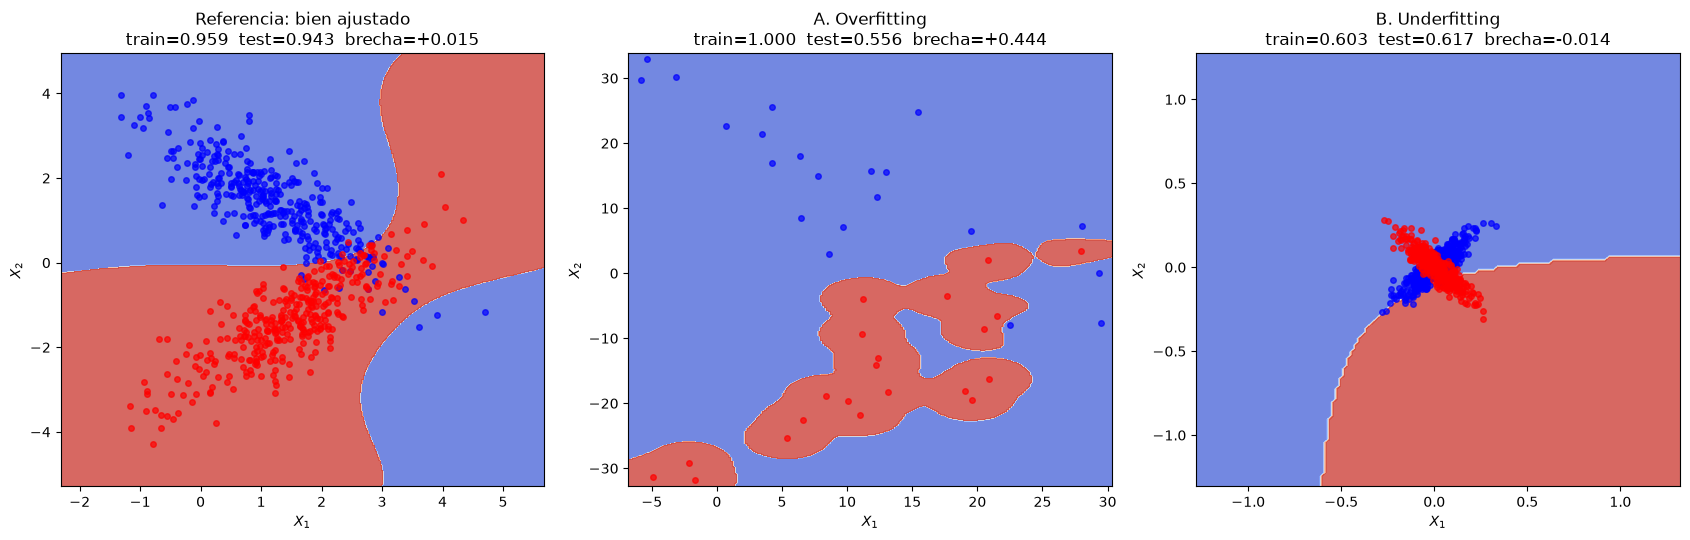

In [16]:
# Fronteras de decision de los tres escenarios
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

evaluar_escenario(X_t, y, gamma_optimo, "Referencia: bien ajustado", ax=axes[0])
evaluar_escenario(X_over, y_over, gamma_optimo, "A. Overfitting", ax=axes[1])
evaluar_escenario(X_under, y_under, gamma_optimo, "B. Underfitting", ax=axes[2])

plt.tight_layout()
plt.show()

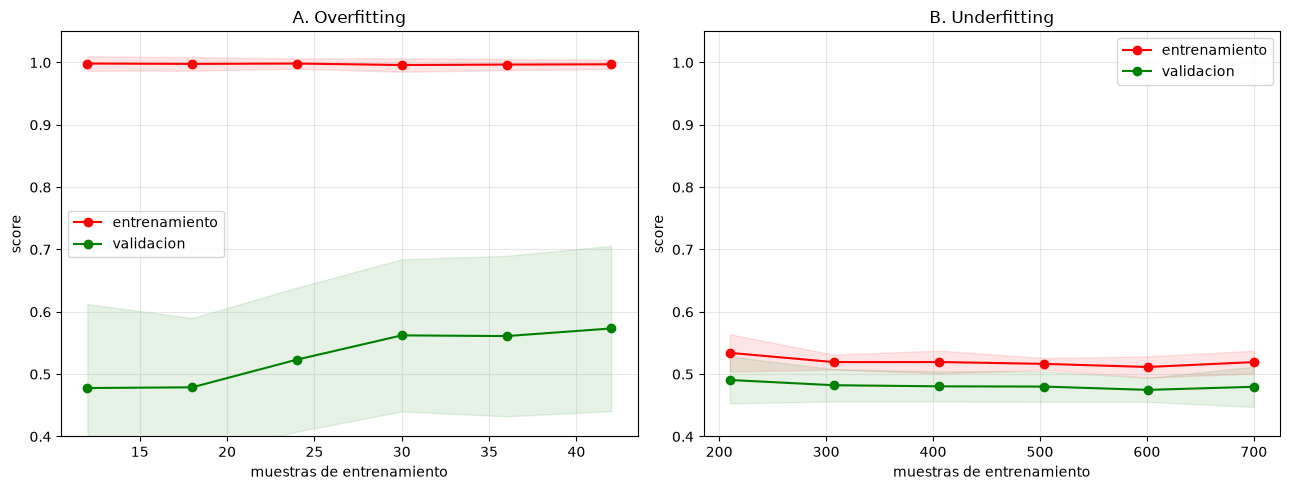

In [17]:
# Curvas de aprendizaje de los dos escenarios extremos
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (Xs, ys, titulo) in zip(axes, [(X_over, y_over, "A. Overfitting"),
                                       (X_under, y_under, "B. Underfitting")]):
    n_splits = 50
    tam, tr, va = learning_curve(
        SVC(gamma=gamma_optimo), Xs, ys,
        cv=ShuffleSplit(n_splits=n_splits, test_size=0.3, random_state=0),
        train_sizes=np.linspace(0.3, 1.0, 6), n_jobs=-1)

    ax.plot(tam, tr.mean(axis=1), "o-", color="r", label="entrenamiento")
    ax.plot(tam, va.mean(axis=1), "o-", color="g", label="validacion")
    ax.fill_between(tam, tr.mean(axis=1) - tr.std(axis=1),
                    tr.mean(axis=1) + tr.std(axis=1), alpha=0.1, color="r")
    ax.fill_between(tam, va.mean(axis=1) - va.std(axis=1),
                    va.mean(axis=1) + va.std(axis=1), alpha=0.1, color="g")
    ax.set_xlabel("muestras de entrenamiento")
    ax.set_ylabel("score")
    ax.set_title(titulo)
    ax.set_ylim(0.4, 1.05)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Control: el diagnostico se confirma reajustando gamma en cada escenario
print("Si el problema es de CAPACIDAD, corregir gamma debe resolverlo:")
print("=" * 95)
evaluar_escenario(X_over, y_over, gamma_optimo, "A. con gamma original")
evaluar_escenario(X_over, y_over, gamma_optimo / 100, "A. con gamma / 100")
print()
evaluar_escenario(X_under, y_under, gamma_optimo, "B. con gamma original")
evaluar_escenario(X_under, y_under, gamma_optimo * 100, "B. con gamma x 100")

Si el problema es de CAPACIDAD, corregir gamma debe resolverlo:
A. con gamma original    n=   60  escala=  14.51  gamma_ef=   60.961  train=1.000  test=0.556  brecha=+0.444
A. con gamma / 100       n=   60  escala=  14.51  gamma_ef=    0.610  train=0.929  test=0.833  brecha=+0.095

B. con gamma original    n= 1000  escala=   0.10  gamma_ef=    0.003  train=0.603  test=0.617  brecha=-0.014
B. con gamma x 100       n= 1000  escala=   0.10  gamma_ef=    0.277  train=0.874  test=0.833  brecha=+0.041


(0.8742857142857143, 0.8333333333333334)

### Analisis del punto 3

Con el modelo fijo en $\gamma = 0.2894$, los tres escenarios dan:

| Escenario | $n$ | $\gamma_{\text{ef}}$ | train | test | brecha |
| --- | --- | --- | --- | --- | --- |
| Referencia | 1000 | 0.55 | 0.959 | 0.943 | +0.015 |
| **A. Overfitting** | 60 | 60.96 | **1.000** | **0.556** | **+0.444** |
| **B. Underfitting** | 1000 | 0.003 | **0.603** | **0.617** | **-0.014** |

**Escenario A: overfitting.** Al ampliar la escala por 10, el gamma efectivo sube a 61, mas
de cien veces el valor adecuado; ademas solo hay 60 muestras. El resultado es la firma
inconfundible del overfitting: **score perfecto en entrenamiento (1.000) y practicamente
azar en test (0.556)**, con una brecha de 0.44. En la frontera de decision se ve por que:
el modelo ha rodeado cada punto de entrenamiento con su propia isla de color en lugar de
trazar una separacion global. No aprendio la estructura de las distribuciones, **memorizo
las 42 muestras concretas** que le tocaron.

**Escenario B: underfitting.** Aqui las dos clases comparten el **mismo centro** y se
distinguen unicamente por la orientacion de sus covarianzas ($\rho=+0.9$ frente a
$\rho=-0.9$): la frontera optima tiene forma de X y es irreduciblemente curva. Al reducir
la escala a 0.1, el gamma efectivo cae a 0.003 y la frontera que el modelo puede trazar es
casi una recta. El resultado es la firma opuesta: **ambos scores bajos (0.603 y 0.617) y
esencialmente iguales**, con brecha nula e incluso ligeramente negativa.

**El contraste entre las dos firmas es el punto central.** Conviene subrayar que el
underfitting **no** se detecta por un score de test bajo: en el escenario A el test tambien
es bajo. Lo que los distingue es la **relacion entre entrenamiento y test**:

- Overfitting: entrenamiento **muy alto**, test bajo $\rightarrow$ brecha grande
  (varianza alta).
- Underfitting: entrenamiento **tambien bajo**, similar al test $\rightarrow$ brecha nula
  (sesgo alto).

Un modelo que no logra ni siquiera ajustar los datos que ya vio no tiene un problema de
generalizacion, sino de **capacidad insuficiente**.

**Las curvas de aprendizaje lo confirman, y matizan el diagnostico.** En el escenario A el
score de entrenamiento se queda clavado en 1.0 mientras el de validacion sube lentamente de
0.48 a 0.57 al pasar de 12 a 42 muestras: la brecha **se estrecha, pero sigue siendo
enorme**. Esa pendiente ascendente de la curva de validacion, que aun no se ha aplanado, es
caracteristica de la varianza alta e indica que en este caso **mas datos si ayudarian**.

En el escenario B ocurre lo contrario: ambas curvas aparecen pegadas desde el comienzo y
completamente **planas** en un nivel bajo (alrededor de 0.5), sin mejora alguna al pasar de
200 a 700 muestras. Mas datos no cambian nada, porque el problema no es falta de
informacion sino falta de flexibilidad. Esta es la utilidad practica de la curva de
aprendizaje: distinguir cuando conviene recolectar mas datos de cuando es inutil hacerlo.

**La verificacion definitiva es el control.** Si el diagnostico es correcto, corregir la
capacidad debe resolver cada caso, y eso es exactamente lo que ocurre:

- En A, dividir $\gamma$ entre 100 elimina la memorizacion y recupera la generalizacion.
- En B, multiplicar $\gamma$ por 100 sube el score de 0.603/0.617 a **0.874/0.833**.

Que el escenario B no llegue mas alto de 0.87 tiene explicacion propia y no contradice
nada: como ambas clases comparten centro y se solapan fuertemente, existe un **error de
Bayes** elevado que ningun clasificador puede superar. Es el mismo techo que aparecio en el
punto 2, solo que mucho mas alto aqui.

## Conclusion general del laboratorio

Los tres puntos recorren el mismo eje conceptual desde angulos distintos. El punto 1 mostro
que el hiperparametro $\gamma$ regula la complejidad de la frontera y que existe un valor
intermedio optimo, localizable con un conjunto de validacion independiente del test. El
punto 2 verifico que ese procedimiento manual coincide exactamente con `GridSearchCV`, y
que las curvas de aprendizaje permiten diagnosticar si conviene recolectar mas datos o
cambiar de modelo. El punto 3 cerro el argumento mostrando que **overfitting y underfitting
no son propiedades del modelo ni de los datos por separado, sino de la relacion entre
ambos**: el mismo clasificador, sin modificar un solo parametro, resulta excesivo para unos
datos e insuficiente para otros.